In [32]:
import os
from langchain_core.prompts import PromptTemplate
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph,START,END,MessagesState
from langchain.messages import RemoveMessage
from langchain_core.messages.utils import trim_messages,count_tokens_approximately
from langchain_core.messages import SystemMessage,HumanMessage,AIMessage
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
load_dotenv()

True

In [33]:
model=ChatGroq(model="openai/gpt-oss-safeguard-20b",temperature=0.2,api_key=os.getenv('GROQ_API_KEY'))

In [34]:
class Chatstate(MessagesState):
    summary:str

In [35]:
def summariztion(state:Chatstate):

    existing_summary=state['summary']

    if existing_summary:
        prompt=f"Existing summary:\n{existing_summary}\n\n"
        "Extend the summary using the new conversation above"
    else:
        prompt="Summarize the following conversation:\n\n"

    msg_for_summary=state["messages"]+[HumanMessage(content=prompt)]

    response=model.invoke(msg_for_summary)

    #keep only last 2 msg
    msg_to_delete=state["messages"][:-2]

    return {
        "summary":response.content,
        "messages":[RemoveMessage(id=msg.id) for msg in msg_to_delete]
    }

In [36]:
def chat_model(state:Chatstate):

   messages=[]

   if state['summary']:
      messages.append(SystemMessage(content=state['summary']))

   messages.extend(state['messages'])
   print(messages)

   response=model.invoke(messages)
   return {"messages": [response]}


In [37]:
def should_summarize(state:Chatstate):
    #summarize if more than 1000 tokens
    return len(state['messages'])> 6

In [38]:
checkpointer=InMemorySaver()

In [39]:
builder = StateGraph(Chatstate)

builder.add_node("chat", chat_model)
builder.add_node("summarize", summariztion)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")

In [40]:
graph=builder.compile(checkpointer=checkpointer)

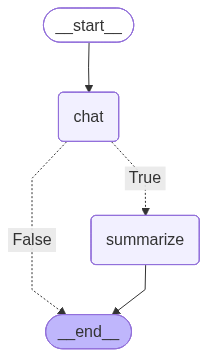

In [41]:
graph

In [42]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [43]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [44]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='abb6b7d8-4501-4e9c-9a9a-959e0e8e831f')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : **Quantum Physics in a Nutshell**

Quantum physics (or quantum mechanics) is the


In [45]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='abb6b7d8-4501-4e9c-9a9a-959e0e8e831f'), AIMessage(content='**Quantum Physics in a Nutshell**\n\nQuantum physics (or quantum mechanics) is the branch of physics that describes the behavior of matter and energy at the smallest scales—atoms, electrons, photons, and other elementary particles. It replaces the deterministic, smooth picture of classical physics with a probabilistic, wave‑like framework that has been experimentally verified to astonishing precision.\n\n---\n\n## 1. Core Principles\n\n| Principle | What it Means | Key Consequences |\n|-----------|---------------|------------------|\n| **Wave‑Particle Duality** | Particles such as electrons exhibit both particle‑like and wave‑like properties. | Interference patterns in double‑slit experiments; electron diffraction. |\n| **Quantization** | Energy, angular momentum, and other observables come in discrete “quanta.” | Atomic spectra, black‑body

In [46]:
run_turn('What are some of Einstien"s fampus work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='abb6b7d8-4501-4e9c-9a9a-959e0e8e831f'), AIMessage(content='**Quantum Physics in a Nutshell**\n\nQuantum physics (or quantum mechanics) is the branch of physics that describes the behavior of matter and energy at the smallest scales—atoms, electrons, photons, and other elementary particles. It replaces the deterministic, smooth picture of classical physics with a probabilistic, wave‑like framework that has been experimentally verified to astonishing precision.\n\n---\n\n## 1. Core Principles\n\n| Principle | What it Means | Key Consequences |\n|-----------|---------------|------------------|\n| **Wave‑Particle Duality** | Particles such as electrons exhibit both particle‑like and wave‑like properties. | Interference patterns in double‑slit experiments; electron diffraction. |\n| **Quantization** | Energy, angular momentum, and other observables come in discrete “quanta.” | Atomic spectra, black‑body

In [47]:
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='abb6b7d8-4501-4e9c-9a9a-959e0e8e831f'), AIMessage(content='**Quantum Physics in a Nutshell**\n\nQuantum physics (or quantum mechanics) is the branch of physics that describes the behavior of matter and energy at the smallest scales—atoms, electrons, photons, and other elementary particles. It replaces the deterministic, smooth picture of classical physics with a probabilistic, wave‑like framework that has been experimentally verified to astonishing precision.\n\n---\n\n## 1. Core Principles\n\n| Principle | What it Means | Key Consequences |\n|-----------|---------------|------------------|\n| **Wave‑Particle Duality** | Particles such as electrons exhibit both particle‑like and wave‑like properties. | Interference patterns in double‑slit experiments; electron diffraction. |\n| **Quantization** | Energy, angular momentum, and other observables come in discrete “quanta.” | Atomic spectra, black‑body